<a href="https://colab.research.google.com/github/Jack00027/Machine-Learning-in-Finance-Exercises/blob/main/Exercise_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training image number 53992 belongs to class: 4 - Coat


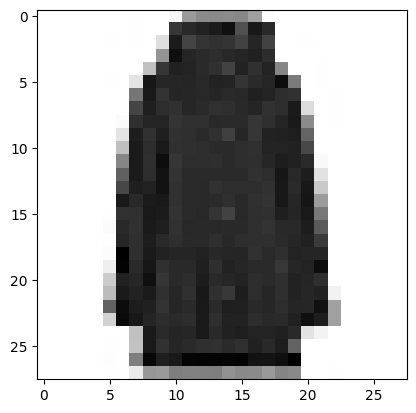

In [1]:
## Loading packages
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

## Load Fashion-MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

## Class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

## Function to display an image
def show(i, T=0):
    if T == 0:
        print("Training image number", i, "belongs to class:", y_train[i], "-", class_names[y_train[i]])
        plt.imshow(x_train[i], cmap='Greys')
        plt.show()
    else:
        print("Test image number", i, "belongs to class:", y_test[i], "-", class_names[y_test[i]])
        plt.imshow(x_test[i], cmap='Greys')
        plt.show()

## Show one random training image
image_index = np.random.randint(60000)
show(image_index)

## Reshape data to 4D tensors for Keras
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1)
input_shape = (28, 28, 1)



In [2]:
## Convert to float
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

## Normalize pixel values to [0,1]
x_train /= 255
x_test /= 255

print("x_train shape:", x_train.shape)
print("Number of training images:", x_train.shape[0])
print("Number of test images:", x_test.shape[0])
print("y_train shape:", y_train.shape)

x_train shape: (60000, 28, 28, 1)
Number of training images: 60000
Number of test images: 10000
y_train shape: (60000,)


In [4]:
## Import model/layers
from keras.models import Model
from keras.layers import Input, Dense, Flatten

## Define model
inputs = Input(shape=input_shape)
outputs = Flatten()(inputs)
outputs = Dense(512, activation='relu')(outputs)
outputs = Dense(256, activation='relu')(outputs)
outputs = Dense(10, activation='softmax')(outputs)

model = Model(inputs=inputs, outputs=outputs)

## Summary
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
## Compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

## Train model
model.fit(x=x_train, y=y_train, epochs=10, batch_size=100)

## Evaluate on test set
results = model.evaluate(x_test, y_test)
print("Test result [loss, accuracy] =", results)

Epoch 1/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7891 - loss: 0.6114
Epoch 2/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8695 - loss: 0.3563
Epoch 3/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8811 - loss: 0.3216
Epoch 4/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8914 - loss: 0.2947
Epoch 5/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8994 - loss: 0.2736
Epoch 6/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9040 - loss: 0.2576
Epoch 7/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9074 - loss: 0.2470
Epoch 8/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9128 - loss: 0.2340
Epoch 9/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9157 - loss: 0.2228
Epoch 10/10
600/600 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9172 - loss: 0.2182
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8875 - loss: 0.3470
Test result [loss, accuracy] = [0.334855318069458, 0.88830000162

Test image index: 8593


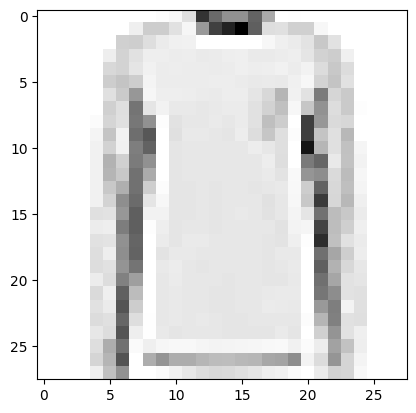

Prediction: 6 - Shirt
Ground truth: 2 - Pullover
Test image index: 9017


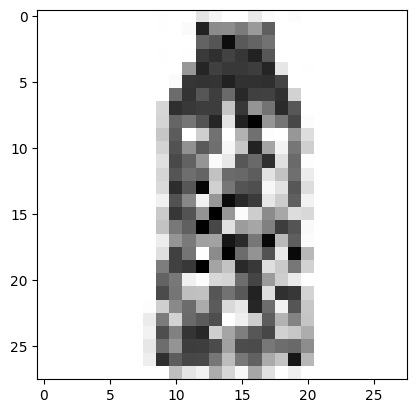

Prediction: 3 - Dress
Ground truth: 0 - T-shirt/top
Test image index: 5470


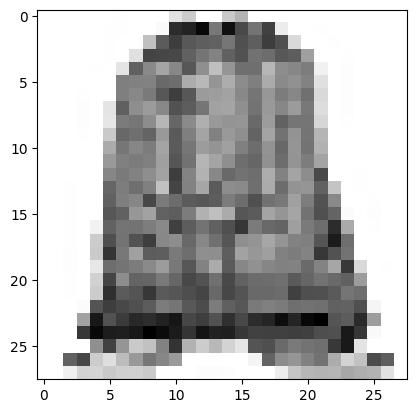

Prediction: 4 - Coat
Ground truth: 8 - Bag
Test image index: 6133


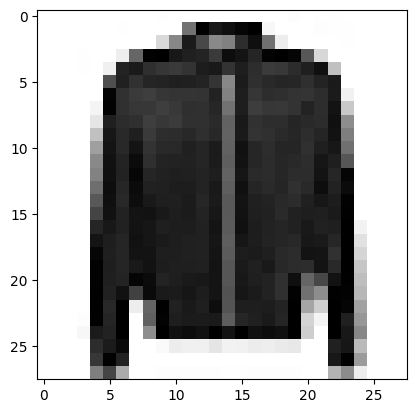

Prediction: 2 - Pullover
Ground truth: 4 - Coat
Test image index: 670


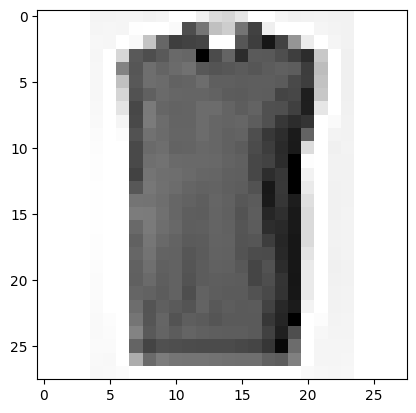

Prediction: 6 - Shirt
Ground truth: 2 - Pullover
Test image index: 4880


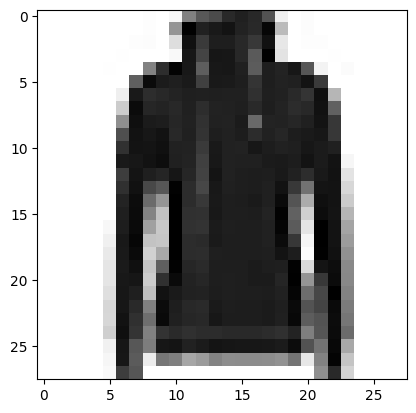

Prediction: 2 - Pullover
Ground truth: 4 - Coat
Test image index: 5307


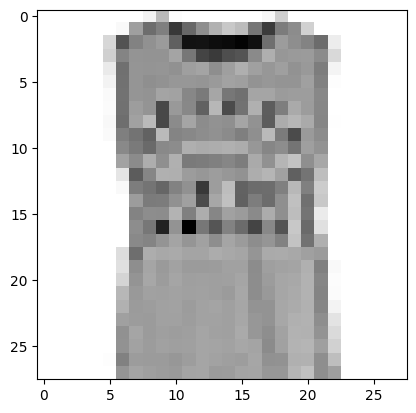

Prediction: 6 - Shirt
Ground truth: 0 - T-shirt/top
Test image index: 6293


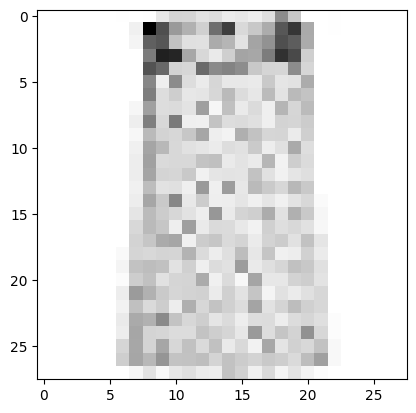

Prediction: 6 - Shirt
Ground truth: 0 - T-shirt/top
Test image index: 6649


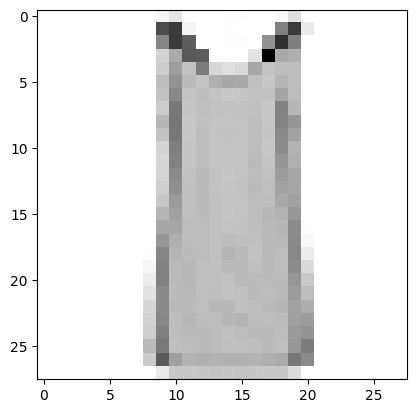

Prediction: 3 - Dress
Ground truth: 0 - T-shirt/top
Test image index: 1659


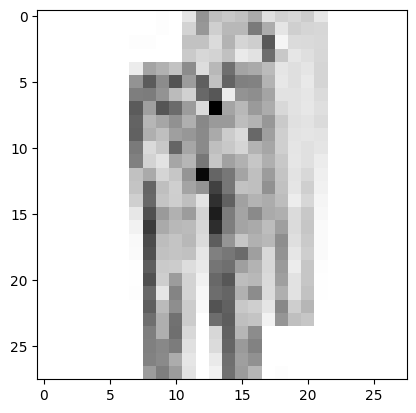

Prediction: 3 - Dress
Ground truth: 1 - Trouser
Test image index: 3988


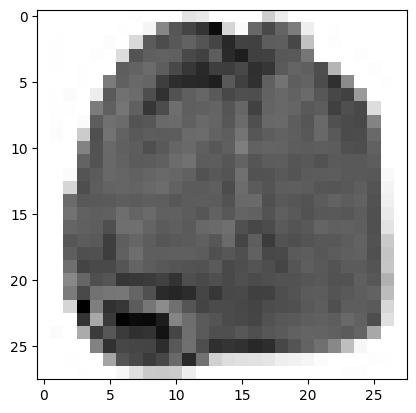

Prediction: 4 - Coat
Ground truth: 8 - Bag
Test image index: 9972


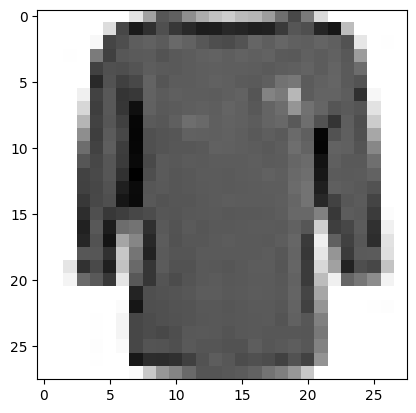

Prediction: 0 - T-shirt/top
Ground truth: 2 - Pullover
Test image index: 8950


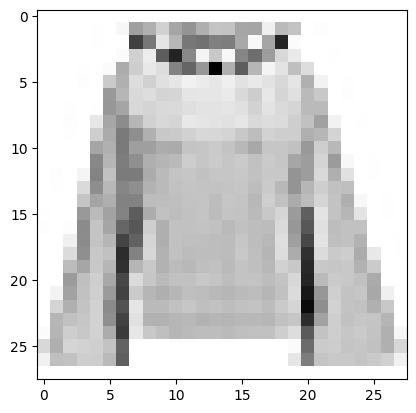

Prediction: 6 - Shirt
Ground truth: 2 - Pullover
Test image index: 1671


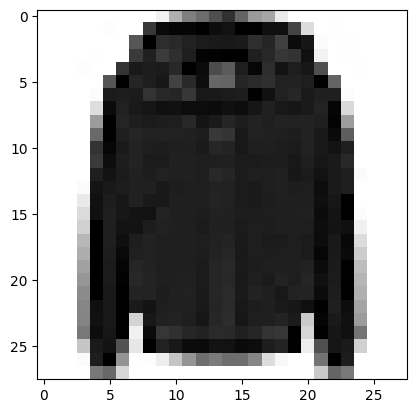

Prediction: 2 - Pullover
Ground truth: 4 - Coat
Test image index: 1482


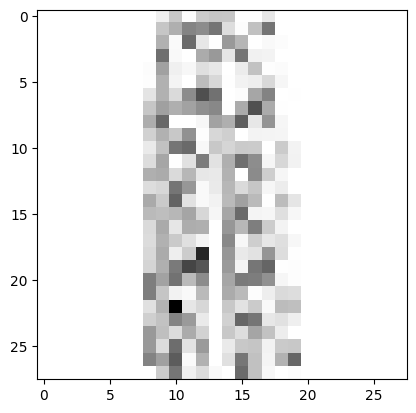

Prediction: 3 - Dress
Ground truth: 1 - Trouser
Test image index: 2659


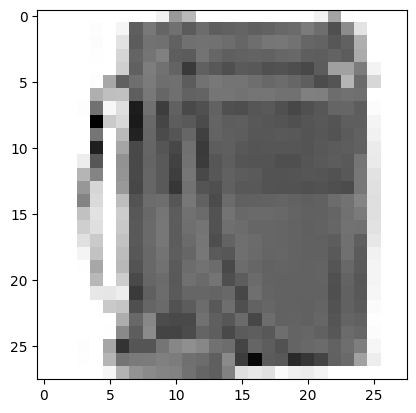

Prediction: 6 - Shirt
Ground truth: 8 - Bag
Total number of parameters: 535818


In [6]:
## Search for some wrongly classified images
img_rows = 28
img_cols = 28

for i in range(100):
    image_index = np.random.randint(10000)
    pred = model.predict(x_test[image_index].reshape(1, img_rows, img_cols, 1), verbose=0)
    predicted_class = pred.argmax()
    true_class = y_test[image_index]

    if predicted_class != true_class:
        print("Test image index:", image_index)
        plt.imshow(x_test[image_index].reshape(28, 28), cmap='Greys')
        plt.show()
        print("Prediction:", predicted_class, "-", class_names[predicted_class])
        print("Ground truth:", true_class, "-", class_names[true_class])

## Number of parameters
print("Total number of parameters:", model.count_params())